In [1]:
import os
import sys
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root:")
print(project_root)

Project root:
d:\anaconda_projects\Neuromorphic\Project_neuromorphic


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [5]:
dataset_path = os.path.join(
    project_root,
    "data",
    "End-to-end dataset",
    "End-to-end dataset",
    "datasets",
    "datasets"
)

print("Dataset path:")
print(dataset_path)

print("\nFolders:")
print(os.listdir(dataset_path))

Dataset path:
d:\anaconda_projects\Neuromorphic\Project_neuromorphic\data\End-to-end dataset\End-to-end dataset\datasets\datasets

Folders:
['forward', 'left', 'right', 'stop']


In [6]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [7]:
dataset = ImageFolder(
    root=dataset_path,
    transform=transform
)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)

Total images: 13536
Classes: ['forward', 'left', 'right', 'stop']
Class mapping: {'forward': 0, 'left': 1, 'right': 2, 'stop': 3}


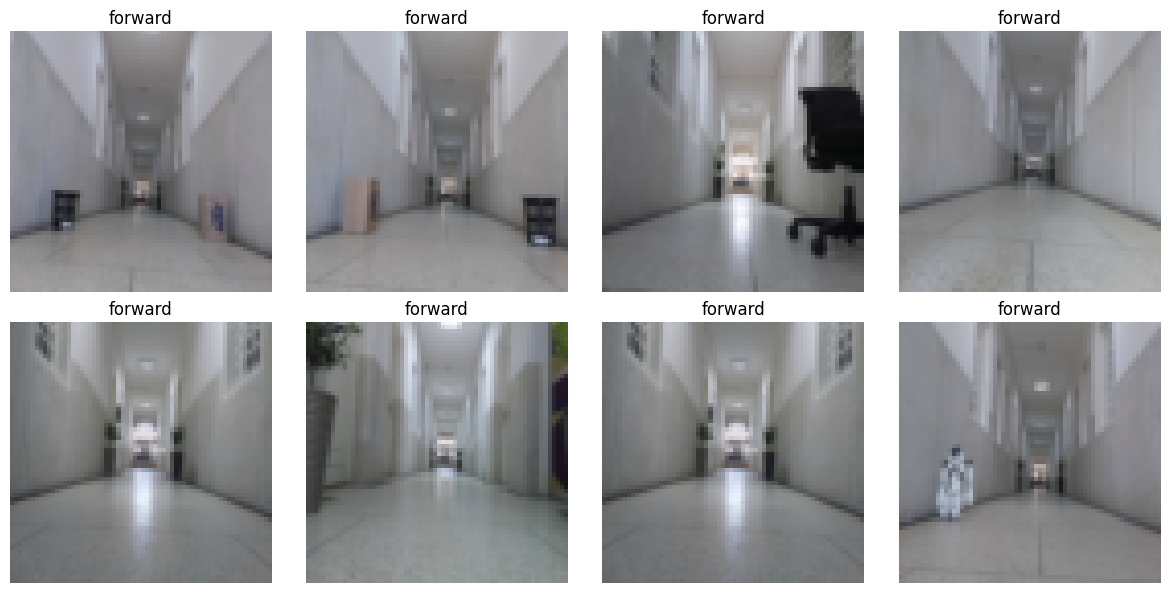

In [8]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(12, 6)
)

for i, ax in enumerate(axes.flat):

    image, label = dataset[i]

    image = image.permute(1, 2, 0)

    ax.imshow(image)

    ax.set_title(
        dataset.classes[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Training images: 10828
Testing images: 2708


In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Batch size:", BATCH_SIZE)

Batch size: 32


In [11]:
images, labels = next(iter(train_loader))

print("Image tensor:", images.shape)
print("Label tensor:", labels.shape)

Image tensor: torch.Size([32, 3, 64, 64])
Label tensor: torch.Size([32])


In [12]:
from models.cnn import CNNNavigation

cnn_model = CNNNavigation().to(device)

print(cnn_model)

CNNNavigation(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [13]:
criterion_cnn = nn.CrossEntropyLoss()

optimizer_cnn = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

In [14]:
def train_cnn(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    epochs=10
):

    history_loss = []
    history_acc = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

        epoch_loss = (
            running_loss /
            len(train_loader)
        )

        epoch_acc = (
            100.0 *
            correct /
            total
        )

        history_loss.append(epoch_loss)
        history_acc.append(epoch_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_acc:.2f}%"
        )

    return history_loss, history_acc

In [18]:
cnn_loss, cnn_acc = train_cnn(
    cnn_model,
    train_loader,
    criterion_cnn,
    optimizer_cnn,
    device,
    epochs=10
)

Epoch [1/10] Loss: 0.1859 Accuracy: 92.33%
Epoch [2/10] Loss: 0.0069 Accuracy: 99.85%
Epoch [3/10] Loss: 0.0002 Accuracy: 100.00%
Epoch [4/10] Loss: 0.0001 Accuracy: 100.00%
Epoch [5/10] Loss: 0.0000 Accuracy: 100.00%
Epoch [6/10] Loss: 0.0000 Accuracy: 100.00%
Epoch [7/10] Loss: 0.0000 Accuracy: 100.00%
Epoch [8/10] Loss: 0.0000 Accuracy: 100.00%
Epoch [9/10] Loss: 0.0000 Accuracy: 100.00%
Epoch [10/10] Loss: 0.0000 Accuracy: 100.00%


In [19]:
def evaluate_cnn(
    model,
    data_loader,
    device
):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in data_loader:

            images = images.to(device)

            outputs = model(images)

            _, predictions = torch.max(
                outputs,
                1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    return (
        accuracy,
        all_labels,
        all_predictions
    )

In [20]:
cnn_test_acc, cnn_true, cnn_pred = evaluate_cnn(
    cnn_model,
    test_loader,
    device
)

print(
    f"CNN Test Accuracy: "
    f"{cnn_test_acc * 100:.2f}%"
)

CNN Test Accuracy: 100.00%


In [21]:
cnn_cm = confusion_matrix(
    cnn_true,
    cnn_pred
)

print(cnn_cm)

[[667   0   0   0]
 [  0 665   0   0]
 [  0   0 665   0]
 [  0   0   0 711]]


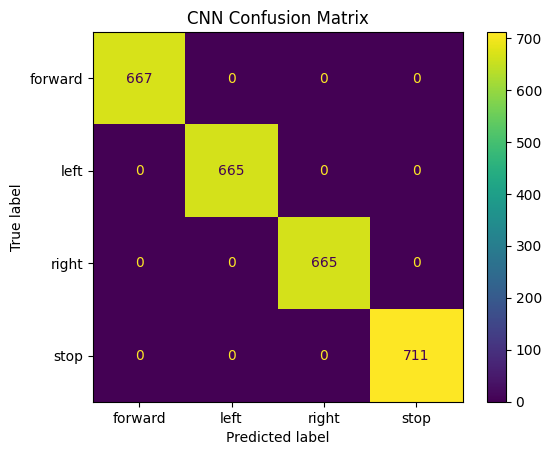

In [22]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm,
    display_labels=dataset.classes
)

disp.plot(
    values_format="d"
)

plt.title("CNN Confusion Matrix")
plt.show()

In [23]:
import snntorch as snn
from snntorch import spikegen
from snntorch import surrogate

In [24]:
import importlib
import models.snn as snn_module

importlib.reload(snn_module)

from models.snn import SpikingNavigation

In [27]:
snn_model = SpikingNavigation(
    num_steps=20
).to(device)

print(snn_model)

SpikingNavigation(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif1): Leaky()
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif2): Leaky()
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif3): Leaky()
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (lif4): Leaky()
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [28]:
images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():

    test_output = snn_model(images)

print("Input shape:", images.shape)
print("Output shape:", test_output.shape)

Input shape: torch.Size([32, 3, 64, 64])
Output shape: torch.Size([20, 32, 4])


In [29]:
criterion_snn = nn.CrossEntropyLoss()

optimizer_snn = optim.Adam(
    snn_model.parameters(),
    lr=0.001
)

In [30]:
def train_snn(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    epochs=10
):

    history_loss = []
    history_acc = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # [time, batch, classes]
            spike_outputs = model(images)

            # Average class output across time
            outputs = spike_outputs.mean(dim=0)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

        epoch_loss = (
            running_loss /
            len(train_loader)
        )

        epoch_acc = (
            100.0 *
            correct /
            total
        )

        history_loss.append(epoch_loss)
        history_acc.append(epoch_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_acc:.2f}%"
        )

    return history_loss, history_acc

In [31]:
snn_loss, snn_acc = train_snn(
    snn_model,
    train_loader,
    criterion_snn,
    optimizer_snn,
    device,
    epochs=10
)

Epoch [1/10] Loss: 0.2247 Accuracy: 92.19%
Epoch [2/10] Loss: 0.0049 Accuracy: 99.99%
Epoch [3/10] Loss: 0.0134 Accuracy: 99.76%
Epoch [4/10] Loss: 0.0029 Accuracy: 99.99%
Epoch [5/10] Loss: 0.0008 Accuracy: 100.00%
Epoch [6/10] Loss: 0.0004 Accuracy: 100.00%
Epoch [7/10] Loss: 0.0003 Accuracy: 100.00%
Epoch [8/10] Loss: 0.0002 Accuracy: 100.00%
Epoch [9/10] Loss: 0.0002 Accuracy: 100.00%
Epoch [10/10] Loss: 0.0001 Accuracy: 100.00%


In [35]:
def evaluate_snn(
    model,
    data_loader,
    device
):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in data_loader:

            images = images.to(device)

            spike_outputs = model(images)

            outputs = spike_outputs.mean(
                dim=0
            )

            _, predictions = torch.max(
                outputs,
                1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    return (
        accuracy,
        all_labels,
        all_predictions
    )

In [36]:
snn_test_acc, snn_true, snn_pred = evaluate_snn(
    snn_model,
    test_loader,
    device
)

print(
    f"SNN Test Accuracy: "
    f"{snn_test_acc * 100:.2f}%"
)

SNN Test Accuracy: 100.00%


In [37]:
snn_cm = confusion_matrix(
    snn_true,
    snn_pred
)

print(snn_cm)

[[667   0   0   0]
 [  0 665   0   0]
 [  0   0 665   0]
 [  0   0   0 711]]


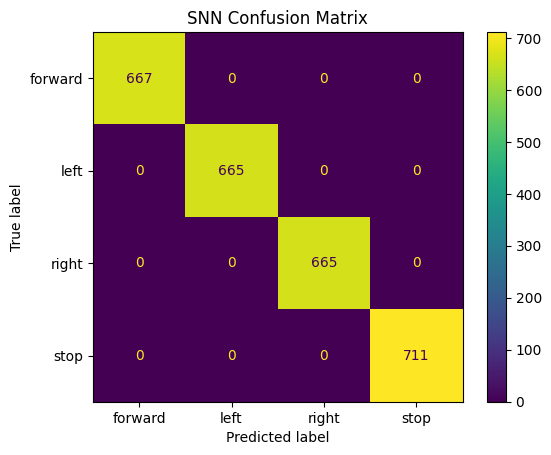

In [38]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=snn_cm,
    display_labels=dataset.classes
)

disp.plot(
    values_format="d"
)

plt.title("SNN Confusion Matrix")
plt.show()

In [39]:
print("=" * 45)
print("CNN vs SNN")
print("=" * 45)

print(
    f"CNN Test Accuracy: "
    f"{cnn_test_acc * 100:.2f}%"
)

print(
    f"SNN Test Accuracy: "
    f"{snn_test_acc * 100:.2f}%"
)

CNN vs SNN
CNN Test Accuracy: 100.00%
SNN Test Accuracy: 100.00%


In [40]:
NUM_STEPS = 20

images, labels = next(
    iter(test_loader)
)

images = images.to(device)

spike_data = spikegen.rate(
    images,
    num_steps=NUM_STEPS
)

print(
    "Original image shape:",
    images.shape
)

print(
    "Spike data shape:",
    spike_data.shape
)

Original image shape: torch.Size([32, 3, 64, 64])
Spike data shape: torch.Size([20, 32, 3, 64, 64])


In [41]:
input_sparsity = (
    (spike_data == 0)
    .float()
    .mean()
    .item()
    * 100
)

print(
    f"Input spike sparsity: "
    f"{input_sparsity:.2f}%"
)

Input spike sparsity: 50.92%


In [42]:
snn_model.eval()

images, labels = next(
    iter(test_loader)
)

images = images.to(device)

with torch.no_grad():

    _ = snn_model(images)

In [43]:
print("Layer-wise Spike Sparsity")
print("=" * 35)

for layer_name, spikes in snn_model.spike_records.items():

    sparsity = (
        (spikes == 0)
        .float()
        .mean()
        .item()
        * 100
    )

    print(
        f"{layer_name}: "
        f"{sparsity:.2f}% sparsity"
    )

Layer-wise Spike Sparsity
lif1: 84.06% sparsity
lif2: 93.80% sparsity
lif3: 93.50% sparsity
lif4: 59.18% sparsity


In [44]:
print("=" * 55)
print("FINAL NEUROMORPHIC ROBOT NAVIGATION RESULTS")
print("=" * 55)

print(
    f"Dataset size: {len(dataset)} images"
)

print(
    f"Classes: {dataset.classes}"
)

print()

print(
    f"CNN Test Accuracy: "
    f"{cnn_test_acc * 100:.2f}%"
)

print(
    f"SNN Test Accuracy: "
    f"{snn_test_acc * 100:.2f}%"
)

print()

print(
    f"Input Spike Sparsity: "
    f"{input_sparsity:.2f}%"
)

print("\nLayer-wise Spike Sparsity:")

for layer_name, spikes in snn_model.spike_records.items():

    sparsity = (
        (spikes == 0)
        .float()
        .mean()
        .item()
        * 100
    )

    print(
        f"{layer_name}: "
        f"{sparsity:.2f}%"
    )

FINAL NEUROMORPHIC ROBOT NAVIGATION RESULTS
Dataset size: 13536 images
Classes: ['forward', 'left', 'right', 'stop']

CNN Test Accuracy: 100.00%
SNN Test Accuracy: 100.00%

Input Spike Sparsity: 50.92%

Layer-wise Spike Sparsity:
lif1: 84.06%
lif2: 93.80%
lif3: 93.50%
lif4: 59.18%


In [45]:
os.makedirs(
    os.path.join(project_root, "results"),
    exist_ok=True
)

torch.save(
    cnn_model.state_dict(),
    os.path.join(
        project_root,
        "results",
        "cnn_navigation.pth"
    )
)

torch.save(
    snn_model.state_dict(),
    os.path.join(
        project_root,
        "results",
        "snn_navigation.pth"
    )
)

print("Models saved successfully.")

Models saved successfully.


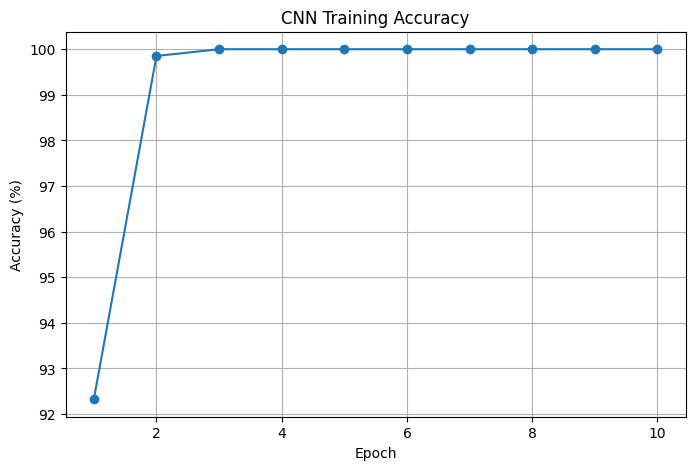

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cnn_acc) + 1),
    cnn_acc,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Training Accuracy")

plt.grid()

plt.show()

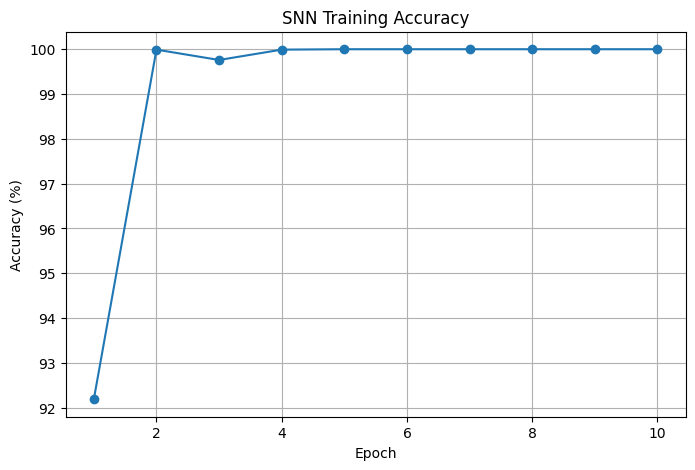

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(snn_acc) + 1),
    snn_acc,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("SNN Training Accuracy")

plt.grid()

plt.show()

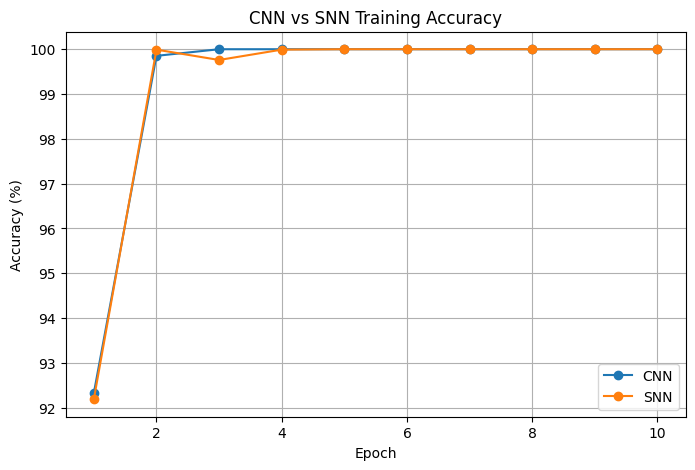

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cnn_acc) + 1),
    cnn_acc,
    marker="o",
    label="CNN"
)

plt.plot(
    range(1, len(snn_acc) + 1),
    snn_acc,
    marker="o",
    label="SNN"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN vs SNN Training Accuracy")

plt.legend()
plt.grid()

plt.show()